# Wine Quality Prediction

**Oasis Infobyte Data Analytics Internship — Level 2, Task 2**

This project compares three machine-learning classifiers to predict red-wine quality from physicochemical measurements. The original quality score is converted into a transparent, three-class target: Low (3–4), Medium (5–6), and High (7–8).

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
DATA_PATH = Path('winequality-red.csv')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

## 1. Load data and inspect quality-score distribution

Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


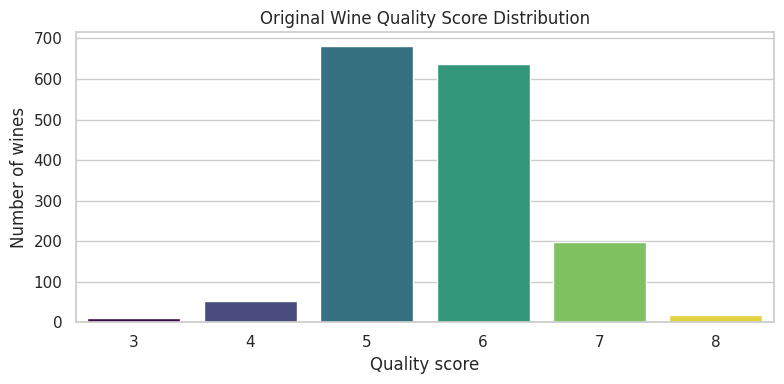

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe().T)

quality_counts = df['quality'].value_counts().sort_index()
display(quality_counts.to_frame('count'))
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df, x='quality', hue='quality', legend=False, palette='viridis', ax=ax)
ax.set(title='Original Wine Quality Score Distribution', xlabel='Quality score', ylabel='Number of wines')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'quality_distribution.png', bbox_inches='tight'); plt.show()

**Observation.** The original quality scores are concentrated in 5 and 6, while scores of 3, 4, 7, and 8 are much less common. This class imbalance makes direct multi-class modelling difficult and must be handled thoughtfully.

## 2. EDA: feature distributions and correlations

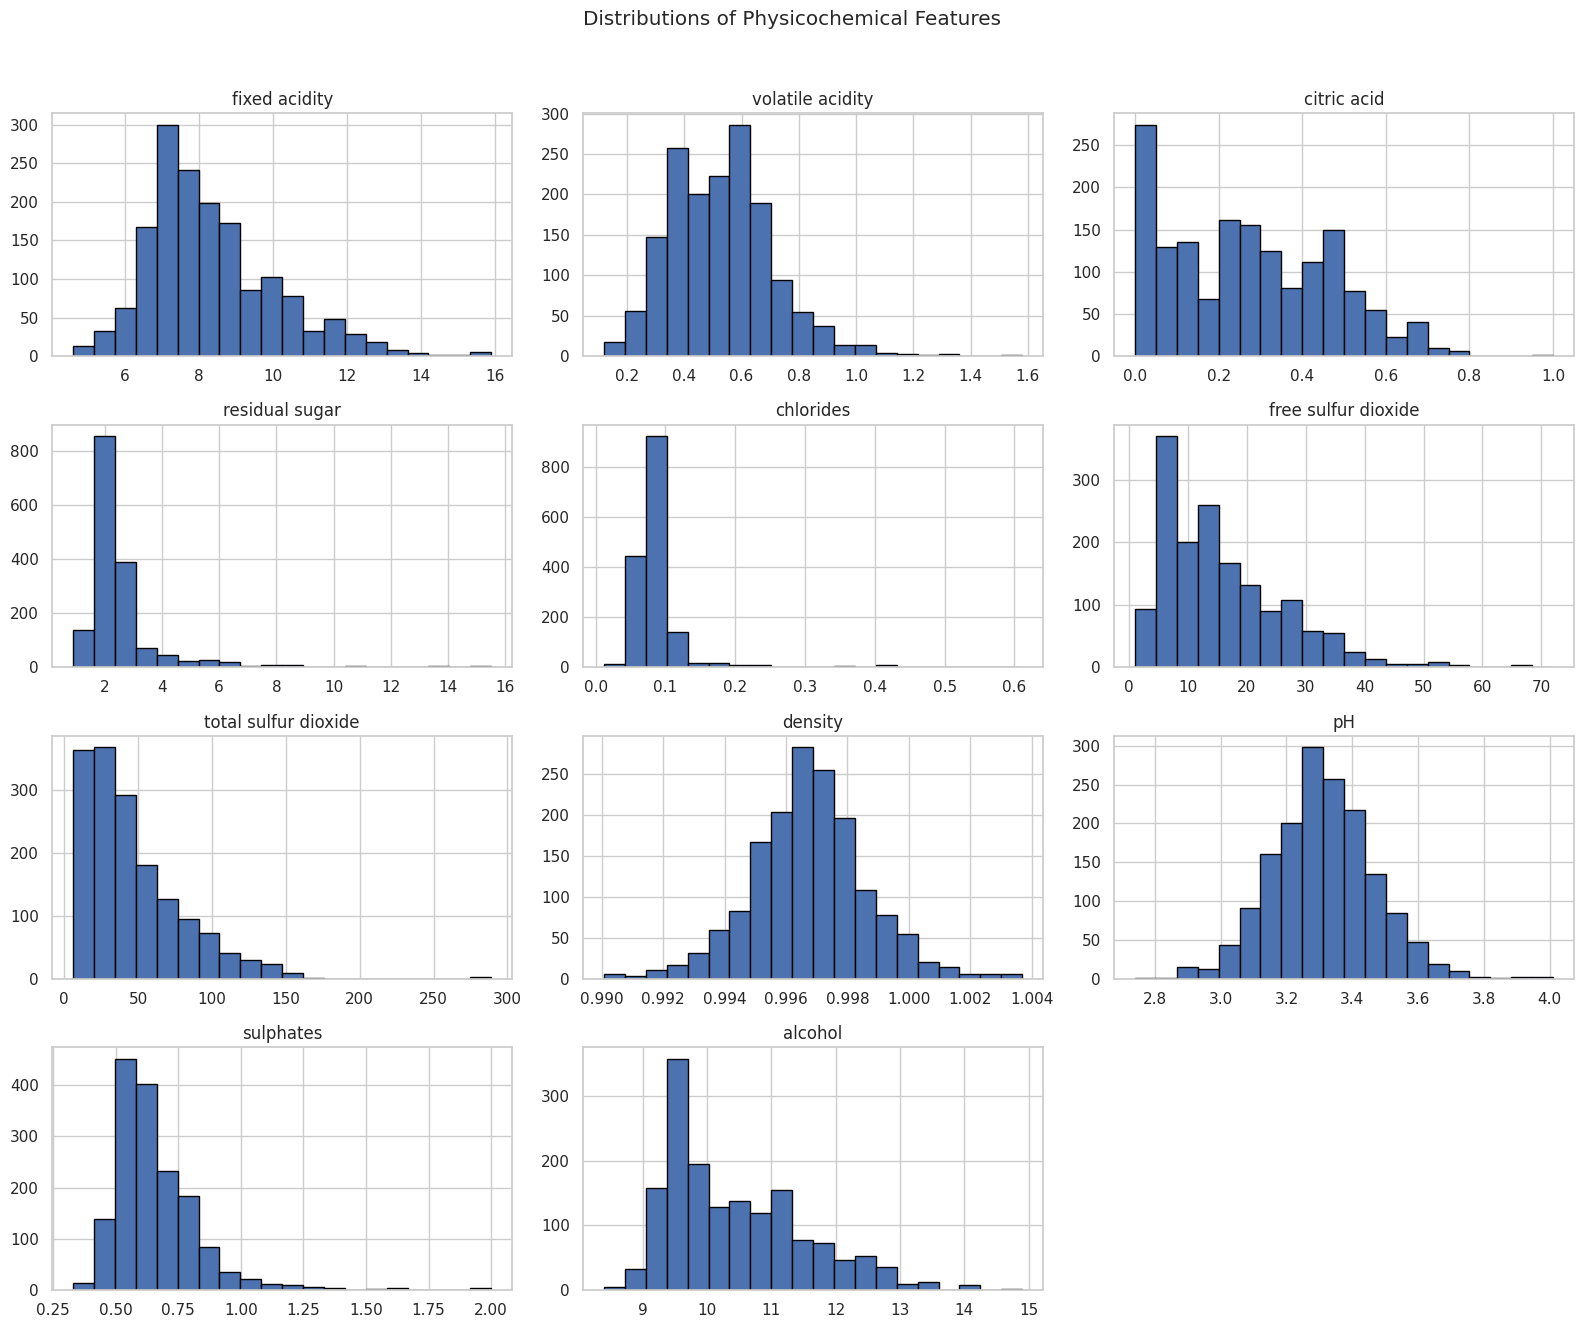

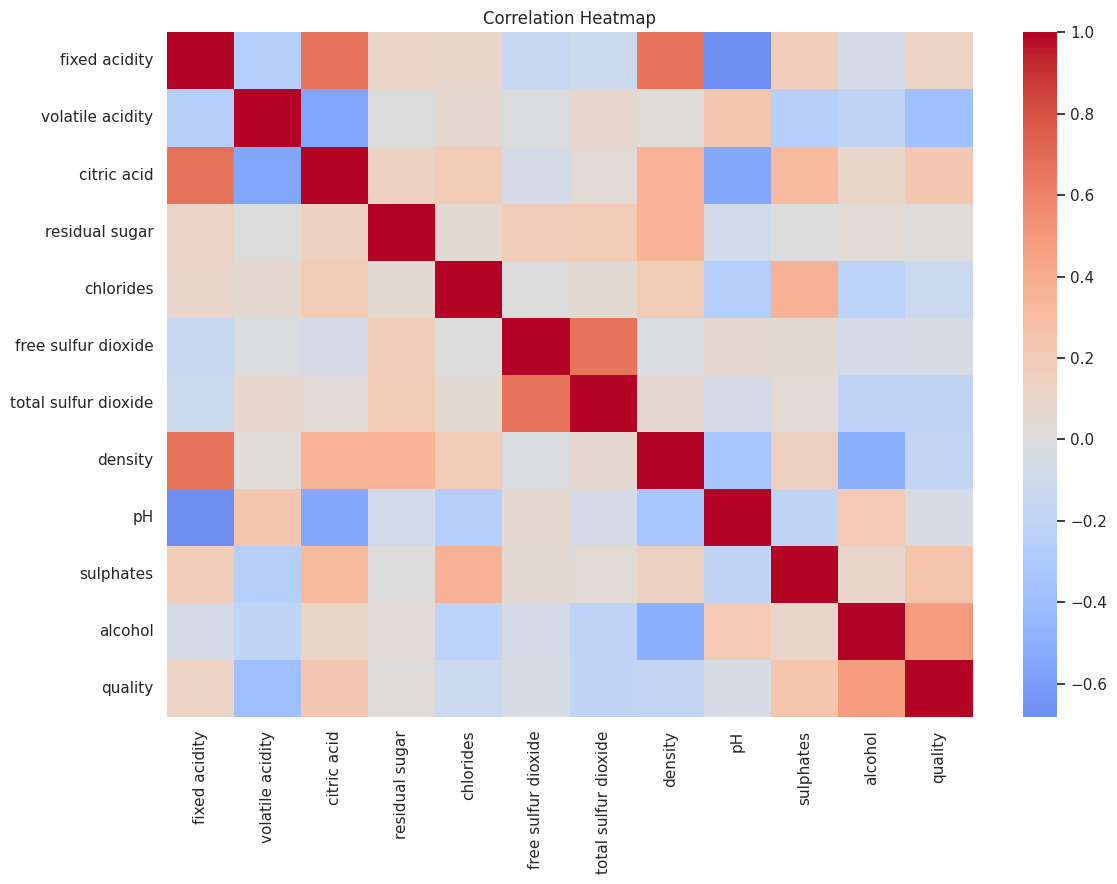

In [3]:
features = df.drop(columns='quality').columns
df[features].hist(figsize=(16, 13), bins=20, edgecolor='black')
plt.suptitle('Distributions of Physicochemical Features', y=1.02)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'feature_distributions.png', bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', bbox_inches='tight'); plt.show()

**Observation.** Several chemical measurements use very different scales, so models sensitive to feature magnitude need standardisation. The correlation heatmap also helps identify properties associated with quality before modelling.

## 3. Feature engineering and class-imbalance decision

,count
quality_group,
Low (3–4),63
Medium (5–6),1319
High (7–8),217


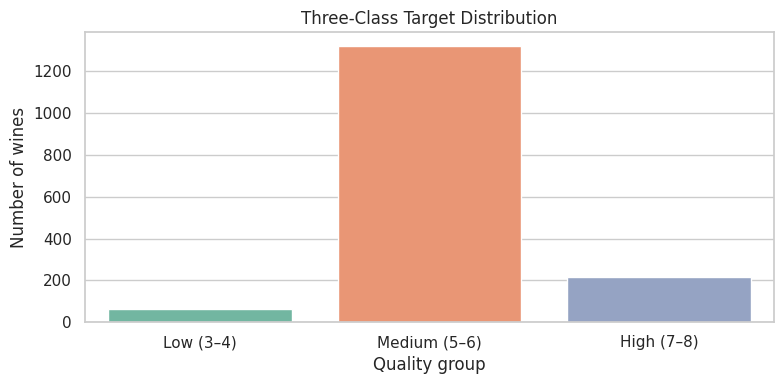

In [4]:
# Three groups preserve more information than a simple good/bad split while reducing sparse classes.
df['quality_group'] = pd.cut(
    df['quality'], bins=[2, 4, 6, 8], labels=['Low (3–4)', 'Medium (5–6)', 'High (7–8)']
)
class_counts = df['quality_group'].value_counts().reindex(['Low (3–4)', 'Medium (5–6)', 'High (7–8)'])
display(class_counts.to_frame('count'))

fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df, x='quality_group', hue='quality_group', legend=False, palette='Set2', ax=ax)
ax.set(title='Three-Class Target Distribution', xlabel='Quality group', ylabel='Number of wines')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'quality_group_distribution.png', bbox_inches='tight'); plt.show()

### Why a three-class target?

The original eight-score scale is highly imbalanced. Combining 3–4 as **Low**, 5–6 as **Medium**, and 7–8 as **High** preserves an interpretable quality range while increasing the number of observations in the rare groups. Stratified splitting keeps these group proportions similar in training and test data.

## 4. Stratified train/test split and three-model comparison

In [5]:
X = df[features]
y = df['quality_group']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print('Training set:', X_train.shape, 'Test set:', X_test.shape)
print('Training class shares:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Test class shares:', y_test.value_counts(normalize=True).round(3).to_dict())

models = {
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced'),
    'SGD Classifier': Pipeline([('scaler', StandardScaler()), ('model', SGDClassifier(loss='log_loss', max_iter=5000, random_state=RANDOM_STATE, class_weight='balanced'))]),
    'Support Vector Classifier': Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE))])
}

results, predictions = [], {}
for name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    predictions[name] = prediction
    results.append({'model': name, 'accuracy': accuracy_score(y_test, prediction)})

comparison = pd.DataFrame(results).sort_values('accuracy', ascending=False).reset_index(drop=True)
display(comparison.style.format({'accuracy': '{:.3f}'}))

Training set: (1279, 11) Test set: (320, 11)
Training class shares: {'Medium (5–6)': 0.825, 'High (7–8)': 0.136, 'Low (3–4)': 0.039}
Test class shares: {'Medium (5–6)': 0.825, 'High (7–8)': 0.134, 'Low (3–4)': 0.041}


,model,accuracy
0,Random Forest,0.881
1,Support Vector Classifier,0.709
2,SGD Classifier,0.647


## 5. Evaluation: classification reports and confusion matrices


Random Forest classification report
              precision    recall  f1-score   support

   Low (3–4)       0.00      0.00      0.00        13
Medium (5–6)       0.89      0.98      0.93       264
  High (7–8)       0.80      0.56      0.66        43

    accuracy                           0.88       320
   macro avg       0.56      0.51      0.53       320
weighted avg       0.84      0.88      0.86       320



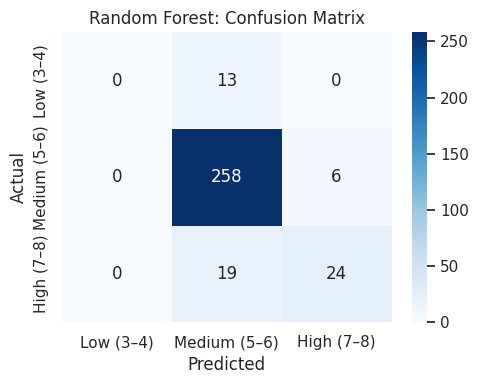


SGD Classifier classification report
              precision    recall  f1-score   support

   Low (3–4)       0.06      0.31      0.10        13
Medium (5–6)       0.89      0.69      0.78       264
  High (7–8)       0.48      0.49      0.48        43

    accuracy                           0.65       320
   macro avg       0.47      0.50      0.45       320
weighted avg       0.80      0.65      0.71       320



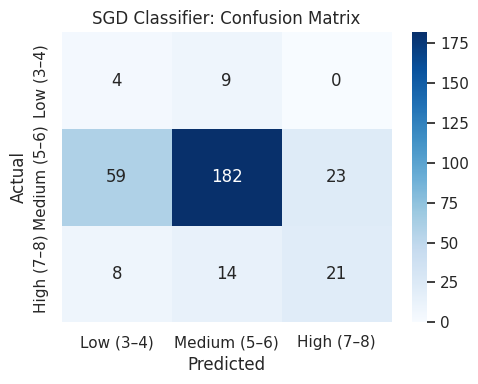


Support Vector Classifier classification report
              precision    recall  f1-score   support

   Low (3–4)       0.10      0.23      0.14        13
Medium (5–6)       0.92      0.73      0.81       264
  High (7–8)       0.40      0.74      0.52        43

    accuracy                           0.71       320
   macro avg       0.47      0.57      0.49       320
weighted avg       0.82      0.71      0.74       320



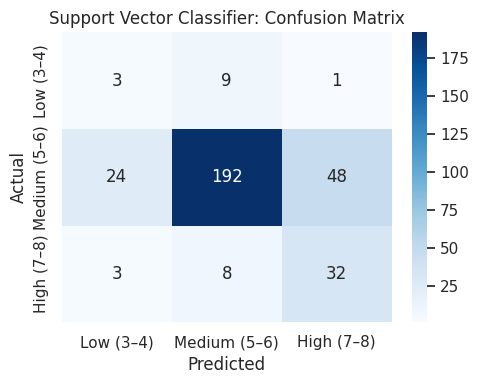

In [6]:
labels = ['Low (3–4)', 'Medium (5–6)', 'High (7–8)']
for name, prediction in predictions.items():
    print(f'\n{name} classification report')
    print(classification_report(y_test, prediction, labels=labels, zero_division=0))
    matrix = confusion_matrix(y_test, prediction, labels=labels)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set(title=f'{name}: Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / f'confusion_matrix_{name.lower().replace(" ", "_")}.png', bbox_inches='tight'); plt.show()

**Interpretation.** Accuracy alone is not enough because the Medium class is larger. Use the precision, recall, F1-score, and confusion matrices to check whether each model is also recognising Low and High quality wines.

## 6. Random Forest feature importance

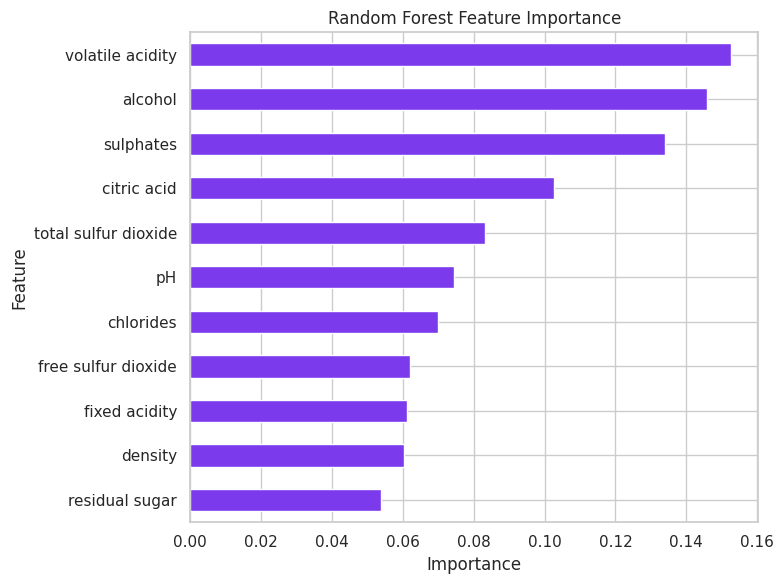

,importance
volatile acidity,0.152694
alcohol,0.145797
sulphates,0.133864
citric acid,0.102588
total sulfur dioxide,0.083132
pH,0.074544
chlorides,0.070007
free sulfur dioxide,0.061957
fixed acidity,0.061164
density,0.060341


In [7]:
rf = models['Random Forest']
importance = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
importance.plot(kind='barh', ax=ax, color='#7c3aed')
ax.set(title='Random Forest Feature Importance', xlabel='Importance', ylabel='Feature')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'random_forest_feature_importance.png', bbox_inches='tight'); plt.show()
display(importance.sort_values(ascending=False).to_frame('importance'))

**Observation.** Feature importance ranks which chemical measurements most influenced the Random Forest’s predictions. These associations are predictive, not proof that changing a single ingredient causes a quality change.

## Conclusion

This notebook compares Random Forest, SGD, and Support Vector classifiers using an 80/20 stratified split. The best deployment candidate should be selected from the comparison table using both overall accuracy and balanced performance across the Low, Medium, and High classes.

### Recommendations

1. Use the top-performing model as a screening aid, then validate predictions with expert tasting.
2. Monitor minority-class recall before deployment; a high overall accuracy can hide weak detection of Low or High wines.
3. Collect more examples of rare quality scores to improve model reliability and reduce class imbalance.

## Reproducibility
Install `requirements.txt`, then run all cells from top to bottom. Generated figures are saved in `outputs/`.